<a href="https://colab.research.google.com/github/Najla-Nuricia/PemMes_244107020091_Najla/blob/main/JS05/JS05_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving voice.csv to voice.csv


In [3]:
# Baca dataset
df = pd.read_csv('voice.csv')

# Cek data
print(df.head())
print(df.shape)
print(df.columns)

   meanfreq        sd    median       Q25       Q75       IQR       skew  \
0  0.059781  0.064241  0.032027  0.015071  0.090193  0.075122  12.863462   
1  0.066009  0.067310  0.040229  0.019414  0.092666  0.073252  22.423285   
2  0.077316  0.083829  0.036718  0.008701  0.131908  0.123207  30.757155   
3  0.151228  0.072111  0.158011  0.096582  0.207955  0.111374   1.232831   
4  0.135120  0.079146  0.124656  0.078720  0.206045  0.127325   1.101174   

          kurt    sp.ent       sfm  ...  centroid   meanfun    minfun  \
0   274.402906  0.893369  0.491918  ...  0.059781  0.084279  0.015702   
1   634.613855  0.892193  0.513724  ...  0.066009  0.107937  0.015826   
2  1024.927705  0.846389  0.478905  ...  0.077316  0.098706  0.015656   
3     4.177296  0.963322  0.727232  ...  0.151228  0.088965  0.017798   
4     4.333713  0.971955  0.783568  ...  0.135120  0.106398  0.016931   

     maxfun   meandom    mindom    maxdom   dfrange   modindx  label  
0  0.275862  0.007812  0.007812  

In [4]:
features = [
    'meanfreq',
    'sd',
    'median',
    'Q25',
    'Q75',
    'IQR',
    'skew',
    'kurt',
    'sp.ent',
    'sfm',
    'mode',
    'centroid',
    'meanfun',
    'minfun',
    'maxfun',
    'meandom',
    'mindom',
    'maxdom',
    'dfrange',
    'modindx'
]

X = df[features]
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
from sklearn.feature_selection import SelectKBest, f_classif

results = []

for k_features in range(2, len(features) + 1):

    selector = SelectKBest(
        score_func=f_classif,
        k=k_features
    )

    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_selected, y_train)

    y_pred = knn.predict(X_test_selected)

    acc = accuracy_score(y_test, y_pred)

    selected_features = [
        features[i]
        for i in selector.get_support(indices=True)
    ]

    results.append({
        'jumlah_fitur': k_features,
        'akurasi': acc,
        'fitur': selected_features
    })

In [6]:
results_df = pd.DataFrame(results)

print(results_df[['jumlah_fitur', 'akurasi']])

    jumlah_fitur   akurasi
0              2  0.977918
1              3  0.977918
2              4  0.976341
3              5  0.981073
4              6  0.985804
5              7  0.982650
6              8  0.981073
7              9  0.985804
8             10  0.984227
9             11  0.974763
10            12  0.974763
11            13  0.973186
12            14  0.974763
13            15  0.976341
14            16  0.977918
15            17  0.977918
16            18  0.977918
17            19  0.977918
18            20  0.976341


In [7]:
best_features_result = results_df.loc[
    results_df['akurasi'].idxmax()
]

print('Jumlah fitur terbaik:', best_features_result['jumlah_fitur'])
print('Akurasi:', best_features_result['akurasi'])
print('Fitur yang digunakan:')
print(best_features_result['fitur'])

Jumlah fitur terbaik: 6
Akurasi: 0.9858044164037855
Fitur yang digunakan:
['sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'meanfun']


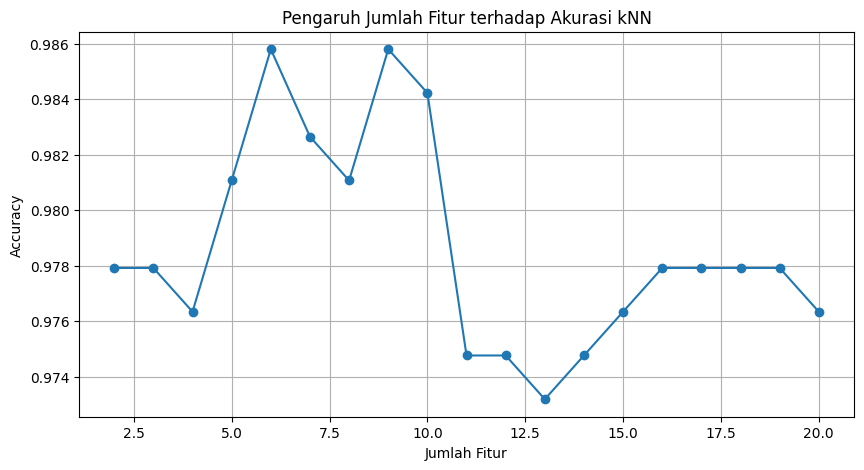

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_df['jumlah_fitur'],
    results_df['akurasi'],
    marker='o'
)

plt.xlabel('Jumlah Fitur')
plt.ylabel('Accuracy')
plt.title('Pengaruh Jumlah Fitur terhadap Akurasi kNN')
plt.grid()

plt.show()

In [10]:
k_values = range(1, 21)
k_results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_best, y_train)

    y_pred = knn.predict(X_test_best)

    acc = accuracy_score(y_test, y_pred)

    k_results.append(acc)

In [11]:
k_df = pd.DataFrame({
    'k': list(k_values),
    'accuracy': k_results
})

print(k_df)

     k  accuracy
0    1  0.985804
1    2  0.984227
2    3  0.987382
3    4  0.985804
4    5  0.985804
5    6  0.985804
6    7  0.981073
7    8  0.982650
8    9  0.977918
9   10  0.981073
10  11  0.979495
11  12  0.977918
12  13  0.977918
13  14  0.976341
14  15  0.976341
15  16  0.979495
16  17  0.977918
17  18  0.976341
18  19  0.976341
19  20  0.976341


In [12]:
best_k_index = k_df['accuracy'].idxmax()

best_k = k_df.loc[best_k_index, 'k']
best_accuracy = k_df.loc[best_k_index, 'accuracy']

print(f'k terbaik: {best_k}')
print(f'Akurasi terbaik: {best_accuracy}')

k terbaik: 3
Akurasi terbaik: 0.9873817034700315


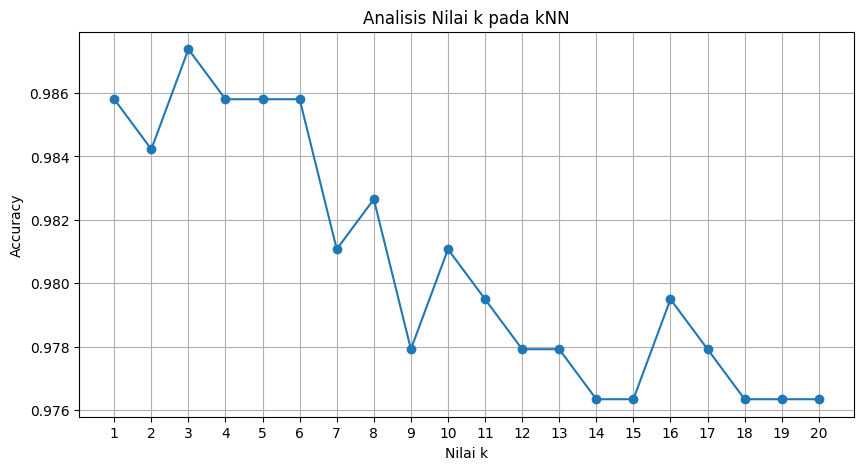

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    k_df['k'],
    k_df['accuracy'],
    marker='o'
)

plt.xlabel('Nilai k')
plt.ylabel('Accuracy')
plt.title('Analisis Nilai k pada kNN')
plt.xticks(list(k_values))
plt.grid()

plt.show()

Pada nomor 2 terdapat 6 fitur terbaik yaitu ['sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'meanfun']

terlihat pada grafik yaitu 0.985804 meskipun sama dengan jumlah fitur 9.

untuk K terbaik yang mencapai puncak keakuratan yaitu pada K=3 terlihat dari grafik k=3 menduduki puncak tertinggi